# PCA in Two Dimensions: Building the Intuition

**This notebook teaches PCA from scratch, it assumes only that you can compute eigenvectors of a $2\times2$ matrix.**

Principal Component Analysis sounds advanced but starts simple: **find the direction a cloud of points spreads out most.** This notebook does exactly that in 2D, by hand, the covariance matrix, its eigenvectors, and the rotation into component coordinates, so it is unmistakable that PCA is the eigenvector machinery from the last section pointed at data.

> Everything here uses plain NumPy. There is a one-line `sklearn` version, and the next notebook uses it, but seeing it done by hand once is the whole point of putting PCA at the end of a *linear algebra* unit.

## Learning objectives

- Compute a **covariance matrix** from a 2D point cloud and read what its entries mean.
- Identify the **principal components** as that matrix's eigenvectors.
- Interpret eigenvalues as **variance explained**, and project the data onto the top component.

## Background

**Variance** measures how spread out one feature is: $\text{var}(x) = \frac{1}{n-1}\sum_i (x_i - \bar{x})^2$. **Covariance** measures whether two features move together:

$$\text{cov}(x, y) = \frac{1}{n-1}\sum_i (x_i - \bar{x})(y_i - \bar{y})$$

Positive means they rise together, negative means one rises as the other falls, zero means no linear relationship. The **covariance matrix** collects all the pairs. For centered data $X$ (each column a feature, each row a sample):

$$\Sigma = \frac{1}{n-1}X^{\top}X = \begin{bmatrix}\text{var}(x) & \text{cov}(x,y)\\ \text{cov}(x,y) & \text{var}(y)\end{bmatrix}$$

Note $\Sigma$ is **symmetric**, $\text{cov}(x,y) = \text{cov}(y,x)$. By §2.6 that guarantees real eigenvalues and **perpendicular** eigenvectors. Those eigenvectors are the **principal components**, and eigenvalue $\lambda_k$ is the variance along component $k$, so the fraction of spread it captures is $\lambda_k / \sum_j \lambda_j$.

## This notebook covers

1. A correlated cloud; centering it.
2. The covariance matrix, computed and read.
3. Its eigenvectors, the principal components, drawn on the scatter.
4. Why they come out perpendicular.
5. Rotating into PC coordinates; variance explained.

**Prerequisites:** `U2-6_Eigen-2_CharacteristicEquation`, `U2-2_Vectors-5_IndependenceAndBasis`

**Dataset:** synthetic correlated 2D data.
**References:** `numpy.linalg.eigh`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
# plotting helper: label the axis ends compactly (for grids of small panels)
def label_axes(ax, x='x', y='y', size=8):
    ax.set_xlabel(x, loc='right', fontsize=size)
    ax.set_ylabel(y, loc='top', rotation=0, fontsize=size)
# plotting helper: draw one vector as an arrow starting at `tail`
# (zorder keeps arrows on top of the axis spines, which are the same white)
def arrow(ax, tail, vec, color, label=None, alpha=1.0):
    ax.quiver(tail[0], tail[1], vec[0], vec[1], angles='xy', scale_units='xy',
              scale=1, color=color, label=label, alpha=alpha, width=0.011, zorder=5)

rng = np.random.default_rng(0)     # fixed seed so the numbers below are reproducible

## 1. A cloud that leans

Make 300 points that clearly trend along a diagonal, think of two lab measurements that tend to rise together. PCA's job is to notice that the cloud has a **long direction** and a **short direction**, and to find them.

First we **center** the data by subtracting each feature's mean. PCA is about spread *around* the middle, so where the cloud sits is irrelevant; only its shape matters.

In [2]:
n = 300
t = rng.normal(0, 1, n)
x = 2.0 * t + rng.normal(0, 0.5, n)          # both features driven by the same hidden t,
y = 1.0 * t + rng.normal(0, 0.5, n)          # so they are correlated
data = np.column_stack([x, y])
data = data + np.array([5.0, 3.0])           # shift it off the origin, to be centered below

centered = data - data.mean(axis=0)
print(f"means before centering: {data.mean(axis=0).round(3)}")
print(f"means after centering : {centered.mean(axis=0).round(3)}")

means before centering: [4.924 2.951]
means after centering : [-0. -0.]


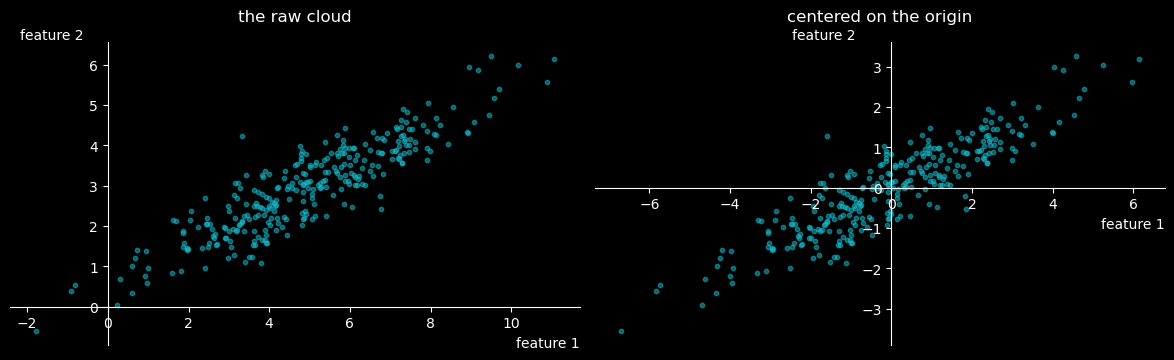

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(data[:, 0], data[:, 1], s=10, alpha=0.5, color="tab:cyan")
axes[0].set_title("the raw cloud", pad=15)
axes[1].scatter(centered[:, 0], centered[:, 1], s=10, alpha=0.5, color="tab:cyan")
axes[1].set_title("centered on the origin", pad=15)
for ax in axes:
    center_axes(ax)
    ax.set_xlabel("feature 1", loc="right")
    ax.set_ylabel("feature 2", loc="top", rotation=0)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 2. The covariance matrix

Now compute $\Sigma = \frac{1}{n-1}X^{\top}X$ on the centered data. Read the four entries:

- **top-left**: the variance of feature 1 (how spread out it is on its own),
- **bottom-right**: the variance of feature 2,
- **off-diagonal** (both the same): the covariance: large and positive here, because the two features rise together.

That off-diagonal number is the entire reason PCA has anything to do. If it were zero the features would already be independent and the axes we have would be the best ones available.

In [4]:
Sigma = (centered.T @ centered) / (len(centered) - 1)
helpers.show(np.round(Sigma, 3), name=r"\Sigma")

print(f"variance of feature 1 : {Sigma[0,0]:.3f}")
print(f"variance of feature 2 : {Sigma[1,1]:.3f}")
print(f"covariance            : {Sigma[0,1]:.3f}   (positive -> they rise together)")
print(f"\nsymmetric? {np.allclose(Sigma, Sigma.T)}   <- guarantees perpendicular eigenvectors")
print(f"numpy agrees? {np.allclose(Sigma, np.cov(centered.T))}")

<IPython.core.display.Math object>

variance of feature 1 : 4.480
variance of feature 2 : 1.300
covariance            : 2.159   (positive -> they rise together)

symmetric? True   <- guarantees perpendicular eigenvectors
numpy agrees? True


## 3. The eigenvectors are the principal components

Here is the whole of PCA, in one line: **take the eigenvectors of the covariance matrix.**

We use `np.linalg.eigh` rather than `eig`, the `h` is for *Hermitian*, meaning symmetric in the real case. It exploits the symmetry to return real eigenvalues in ascending order with guaranteed-perpendicular eigenvectors. We reverse the order so the biggest comes first.

The first eigenvector, **PC1**, is the direction of greatest spread. The second is perpendicular to it, and is whatever spread is left over.

In [5]:
eigenvalues, eigenvectors = np.linalg.eigh(Sigma)

order = np.argsort(eigenvalues)[::-1]        # largest variance first
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# eigenvectors are DIRECTIONS -- the sign is arbitrary, so numpy's choice can point
# a component "backwards". Fix it by convention: make each component's largest
# loading positive, so the pictures and the story below stay consistent.
for k in range(eigenvectors.shape[1]):
    if eigenvectors[np.argmax(np.abs(eigenvectors[:, k])), k] < 0:
        eigenvectors[:, k] *= -1

helpers.show(np.round(eigenvalues, 3), label="eigenvalues (variance along each component)")
helpers.show(np.round(eigenvectors, 3), label="eigenvectors, as columns: PC1, PC2")

print(f"perpendicular? PC1 . PC2 = {np.dot(eigenvectors[:, 0], eigenvectors[:, 1]):.1e}")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

perpendicular? PC1 . PC2 = 0.0e+00


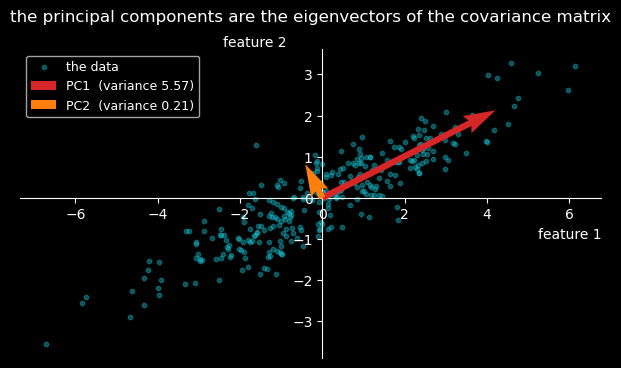

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(centered[:, 0], centered[:, 1], s=10, alpha=0.4, color="tab:cyan", label="the data")

# each component, drawn with a length showing how much variance it carries
for k, color in zip(range(2), ["tab:red", "tab:orange"]):
    scale = 2 * np.sqrt(eigenvalues[k])
    arrow(ax, (0, 0), scale * eigenvectors[:, k], color,
          f"PC{k+1}  (variance {eigenvalues[k]:.2f})")

center_axes(ax)
ax.set_xlabel("feature 1", loc="right")
ax.set_ylabel("feature 2", loc="top", rotation=0)
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=9)
ax.set_title("the principal components are the eigenvectors of the covariance matrix", pad=20)
plt.show()

PC1 runs straight down the long axis of the cloud, and PC2 crosses it at a right angle. Nobody told the algorithm where the cloud pointed, that information was already in the covariance matrix, and taking its eigenvectors extracted it.

## 4. Variance explained

The eigenvalues *are* the variances along their components, so the fraction of the total spread captured by component $k$ is

$$\frac{\lambda_k}{\lambda_1 + \lambda_2 + \cdots}$$

This is the number that justifies dimensionality reduction: if PC1 alone carries most of the variance, describing each point by its position along PC1 loses very little. That is the whole promise of PCA, fewer numbers per data point, most of the information kept.

In [7]:
explained = eigenvalues / eigenvalues.sum()
for k, frac in enumerate(explained):
    print(f"PC{k+1}: variance {eigenvalues[k]:6.3f}   =  {frac:5.1%} of the total")
print(f"\ntotal variance {eigenvalues.sum():.3f} — the same as the sum of the original "
      f"feature variances ({Sigma[0,0] + Sigma[1,1]:.3f}); PCA redistributes spread, it doesn't create it")

PC1: variance  5.571   =  96.4% of the total
PC2: variance  0.209   =   3.6% of the total

total variance 5.781 — the same as the sum of the original feature variances (5.781); PCA redistributes spread, it doesn't create it


## 5. Rotating into component coordinates

The components are a new **basis**, a new pair of perpendicular axes to measure against (exactly the change of basis from §2.2). To re-express each point in that basis, project it onto each component:

$$\text{scores} = X_{\text{centered}} \, V$$

where $V$ has the components as columns. The result is the same cloud, viewed with PC1 horizontal.

Two things to notice in the rotated picture: the cloud is now aligned with the axes, and its covariance matrix has become **diagonal**, in this basis the two coordinates are uncorrelated. That is what PCA is *for*: it finds the rotation that removes the correlation.

In [8]:
scores = centered @ eigenvectors          # each row: [how far along PC1, how far along PC2]

Sigma_rotated = np.cov(scores.T)
helpers.show(np.round(Sigma_rotated, 6), label="covariance in PC coordinates")
print("off-diagonal is zero -> the two new coordinates are uncorrelated")
print("the diagonal is just the eigenvalues:", np.round(np.diag(Sigma_rotated), 3))

<IPython.core.display.Math object>

off-diagonal is zero -> the two new coordinates are uncorrelated
the diagonal is just the eigenvalues: [5.571 0.209]


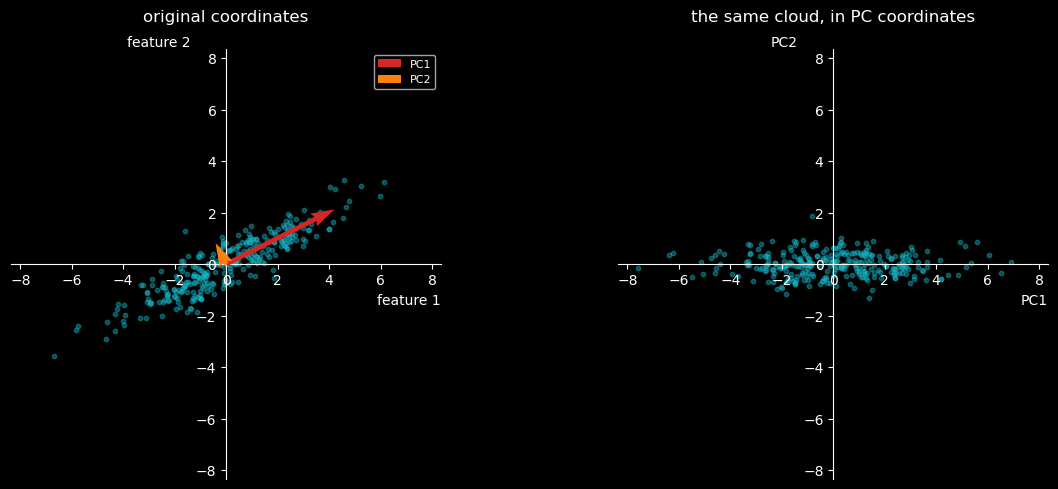

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(centered[:, 0], centered[:, 1], s=10, alpha=0.4, color="tab:cyan")
for k, color in zip(range(2), ["tab:red", "tab:orange"]):
    arrow(ax, (0, 0), 2 * np.sqrt(eigenvalues[k]) * eigenvectors[:, k], color, f"PC{k+1}")
ax.set_xlabel("feature 1", loc="right")
ax.set_ylabel("feature 2", loc="top", rotation=0)
ax.set_title("original coordinates", pad=20)
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(scores[:, 0], scores[:, 1], s=10, alpha=0.4, color="tab:cyan")
ax.set_xlabel("PC1", loc="right")
ax.set_ylabel("PC2", loc="top", rotation=0)
ax.set_title("the same cloud, in PC coordinates", pad=20)

lim = np.abs(np.concatenate([centered, scores])).max() * 1.1
for ax in axes:
    center_axes(ax)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
plt.tight_layout()
plt.show()

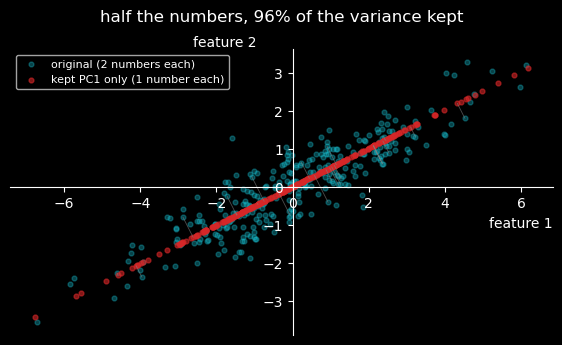

mean squared error from dropping PC2: 0.2085
which is the discarded eigenvalue:    0.2092


In [10]:
# dropping PC2: describe every point by ONE number and rebuild it
scores_pc1_only = scores[:, 0]
rebuilt = np.outer(scores_pc1_only, eigenvectors[:, 0])

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(centered[:, 0], centered[:, 1], s=12, alpha=0.35, color="tab:cyan", label="original (2 numbers each)")
ax.scatter(rebuilt[:, 0], rebuilt[:, 1], s=12, alpha=0.6, color="tab:red", label="kept PC1 only (1 number each)")
for i in range(0, len(centered), 12):
    ax.plot([centered[i, 0], rebuilt[i, 0]], [centered[i, 1], rebuilt[i, 1]],
            color="gray", lw=0.6, alpha=0.6)

center_axes(ax)
ax.set_xlabel("feature 1", loc="right")
ax.set_ylabel("feature 2", loc="top", rotation=0)
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=8)
ax.set_title(f"half the numbers, {explained[0]:.0%} of the variance kept", pad=20)
plt.show()

lost = np.mean(np.sum((centered - rebuilt) ** 2, axis=1))
print(f"mean squared error from dropping PC2: {lost:.4f}")
print(f"which is the discarded eigenvalue:    {eigenvalues[1]:.4f}")

## 6. Summary

- **Center** the data, then compute the **covariance matrix** $\Sigma = \frac{1}{n-1}X^{\top}X$. Its off-diagonal entries say how the features move together.
- $\Sigma$ is **symmetric**, so (by §2.6) its eigenvectors are real and **perpendicular**. Those eigenvectors are the **principal components**.
- The **eigenvalues are the variances** along each component; $\lambda_k / \sum_j\lambda_j$ is the fraction of spread explained.
- Projecting onto the components rotates the cloud so it aligns with the axes and the coordinates become **uncorrelated**.
- Keeping only the top components **reduces dimension**, and the error is exactly the eigenvalues you dropped.

PCA is not a new technique, it is §2.6's eigen-decomposition applied to a covariance matrix.

Next: the same procedure on a real table with many columns (`U2-7_PCA-2_RealEstate`).